In [2]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import root_scalar

HL_TREE_FILE = "hl_tree.parquet"
BDT_TREE_FILE = "bdt_tree.parquet"
MARKET_CURVE_FILE = "market_curve.parquet"


# =============================================================================
# HARD-CODED SETTINGS
# =============================================================================
dt = 0.5
T = 10.0
L0 = 100.0
N_STEPS = int(round(T / dt))


# =============================================================================
# LOAD PART (A) DATA
# =============================================================================

def dataframe_to_tree(tree_df):
    tree = []
    for step, grp in tree_df.sort_values(["step", "node"]).groupby("step"):
        r_step = grp.sort_values("node")["short_rate_cc"].to_numpy(dtype=float)
        tree.append(r_step)
    return tree

def load_part_a_data(load_market_curve=False):
    hl_tree_df = pd.read_parquet(HL_TREE_FILE)
    bdt_tree_df = pd.read_parquet(BDT_TREE_FILE)

    hl_tree = dataframe_to_tree(hl_tree_df)
    bdt_tree = dataframe_to_tree(bdt_tree_df)

    if len(hl_tree) != N_STEPS:
        raise ValueError(f"HL tree has {len(hl_tree)} steps, expected {N_STEPS}.")
    if len(bdt_tree) != N_STEPS:
        raise ValueError(f"BDT tree has {len(bdt_tree)} steps, expected {N_STEPS}.")

    out = {
        "hl_tree": hl_tree,
        "bdt_tree": bdt_tree,
    }

    if load_market_curve and os.path.exists(MARKET_CURVE_FILE):
        out["market_curve"] = pd.read_parquet(MARKET_CURVE_FILE)

    return out

# =============================================================================
# PART (B) -> MORTGAGE PRICING IN THE LECTURE-NOTES STYLE
#
# 1) No-prepayment mortgage tree V_np
# 2) Prepayment option tree C
# 3) Mortgage value tree V = V_np - C
# =============================================================================

def mortgage_payment(K, L0=100.0, T=10.0, dt=0.5):
    """
    K = annual nominal mortgage rate with semiannual payments.
    Periodic rate = K * dt.
    """
    M = int(round(T / dt))
    k = K * dt
    if abs(k) < 1e-14:
        return L0 / M
    return L0 * k / (1.0 - (1.0 + k) ** (-M))

def outstanding_balance_schedule(K, L0=100.0, T=10.0, dt=0.5):
    """
    Outstanding balance immediately after each payment:
    L[0], L[1], ..., L[M]
    """
    M = int(round(T / dt))
    A = mortgage_payment(K, L0=L0, T=T, dt=dt)
    k = K * dt

    L = np.zeros(M + 1)
    L[0] = L0

    for i in range(M):
        interest_paid = L[i] * k
        principal_paid = A - interest_paid
        L[i + 1] = max(L[i] - principal_paid, 0.0)

    if abs(L[-1]) < 1e-10:
        L[-1] = 0.0

    return L

def price_mortgage_no_prepay(tree, K, L0=100.0, T=10.0, dt=0.5):
    """
    V_np[i,j] = exp(-r[i,j]*dt) * (A + 0.5*V_np[i+1,j] + 0.5*V_np[i+1,j+1])
    with terminal V_np[M,j] = 0.
    """
    M = int(round(T / dt))
    if len(tree) != M:
        raise ValueError(f"Tree length must be {M}, got {len(tree)}.")

    A = mortgage_payment(K, L0=L0, T=T, dt=dt)
    L = outstanding_balance_schedule(K, L0=L0, T=T, dt=dt)

    Vnp_tree = [None] * (M + 1)
    Vnp_tree[M] = np.zeros(M + 1)

    for i in range(M - 1, -1, -1):
        r_i = np.asarray(tree[i], dtype=float)
        V_next = Vnp_tree[i + 1]
        V_i = np.zeros(i + 1)

        for j in range(i + 1):
            V_i[j] = np.exp(-r_i[j] * dt) * (A + 0.5 * V_next[j] + 0.5 * V_next[j + 1])

        Vnp_tree[i] = V_i

    return Vnp_tree, A, L

def price_prepayment_option(tree, Vnp_tree, L, T=10.0, dt=0.5):
    M = int(round(T / dt))
    C_tree = [None] * (M + 1)
    C_tree[M] = np.zeros(M + 1)

    for i in range(M - 1, -1, -1):
        r_i = np.asarray(tree[i], dtype=float)
        C_next = C_tree[i + 1]
        Vnp_i = Vnp_tree[i]
        C_i = np.zeros(i + 1)

        for j in range(i + 1):
            C_wait = np.exp(-r_i[j] * dt) * (0.5 * C_next[j] + 0.5 * C_next[j + 1])

            # no exercise at origination
            if i == 0:
                C_i[j] = C_wait
            else:
                C_ex = max(Vnp_i[j] - L[i], 0.0)
                C_i[j] = max(C_wait, C_ex)

        C_tree[i] = C_i

    return C_tree

def combine_mortgage_and_option(Vnp_tree, C_tree):
    return [np.asarray(vnp) - np.asarray(c) for vnp, c in zip(Vnp_tree, C_tree)]

def price_mortgage_notes_style(tree, K, L0=100.0, T=10.0, dt=0.5):
    Vnp_tree, A, L = price_mortgage_no_prepay(tree, K, L0=L0, T=T, dt=dt)
    C_tree = price_prepayment_option(tree, Vnp_tree, L, T=T, dt=dt)
    V_tree = combine_mortgage_and_option(Vnp_tree, C_tree)

    return {
        "K": K,
        "payment": A,
        "balance_schedule": L,
        "Vnp_tree": Vnp_tree,
        "C_tree": C_tree,
        "V_tree": V_tree,
        "V0_no_prepay": float(Vnp_tree[0][0]),
        "C0_prepay_option": float(C_tree[0][0]),
        "V0_mortgage": float(V_tree[0][0]),
    }

def find_root_bracket(f, lo=1e-6, hi=0.30, expand=1.5, max_iter=50):
    flo = f(lo)
    fhi = f(hi)
    n = 0
    while flo * fhi > 0 and n < max_iter:
        hi *= expand
        fhi = f(hi)
        n += 1
    if flo * fhi > 0:
        raise RuntimeError("Could not bracket par mortgage rate root.")
    return lo, hi

def solve_par_mortgage_rate(tree, L0=100.0, T=10.0, dt=0.5):
    def objective(K):
        res = price_mortgage_notes_style(tree, K, L0=L0, T=T, dt=dt)
        return res["V0_mortgage"] - L0

    lo, hi = find_root_bracket(objective, lo=1e-6, hi=0.30)
    sol = root_scalar(objective, bracket=[lo, hi], method="brentq")
    return sol.root

# =============================================================================
# RUN PART (B)
# =============================================================================

loaded = load_part_a_data(load_market_curve=True)

hl_tree = loaded["hl_tree"]
bdt_tree = loaded["bdt_tree"]

K_HL = solve_par_mortgage_rate(hl_tree, L0=L0, T=T, dt=dt)
K_BDT = solve_par_mortgage_rate(bdt_tree, L0=L0, T=T, dt=dt)

res_HL = price_mortgage_notes_style(hl_tree, K_HL, L0=L0, T=T, dt=dt)
res_BDT = price_mortgage_notes_style(bdt_tree, K_BDT, L0=L0, T=T, dt=dt)

comparison = pd.DataFrame([
    {
        "model": "HL",
        "K_annual_nominal": res_HL["K"],
        "payment": res_HL["payment"],
        "V0_no_prepay": res_HL["V0_no_prepay"],
        "C0_prepay_option": res_HL["C0_prepay_option"],
        "V0_mortgage": res_HL["V0_mortgage"],
    },
    {
        "model": "BDT",
        "K_annual_nominal": res_BDT["K"],
        "payment": res_BDT["payment"],
        "V0_no_prepay": res_BDT["V0_no_prepay"],
        "C0_prepay_option": res_BDT["C0_prepay_option"],
        "V0_mortgage": res_BDT["V0_mortgage"],
    },
])

print("\nPart (b) results")
print(comparison.to_string(index=False))

if res_HL["K"] > res_BDT["K"]:
    print("\nHL gives the higher par mortgage rate.")
elif res_HL["K"] < res_BDT["K"]:
    print("\nBDT gives the higher par mortgage rate.")
else:
    print("\nThe two models give the same par mortgage rate up to numerical precision.")


Part (b) results
model  K_annual_nominal  payment  V0_no_prepay  C0_prepay_option  V0_mortgage
   HL          0.048665 6.374324    104.740210          4.740210        100.0
  BDT          0.046885 6.320724    103.859491          3.859491        100.0

HL gives the higher par mortgage rate.


In [7]:
import numpy as np
import pandas as pd

# =============================================================================
# PART (C): PASS-THROUGH, PO, IO
# Slides logic:
# 1) Compute borrower-optimal prepayment policy from the mortgage in part (b)
# 2) Reuse that same policy to value PT / PO / IO
# =============================================================================

def mortgage_cashflow_schedule(K_mort, L0=100.0, T=10.0, dt=0.5):
    """
    Underlying mortgage cash flows (borrower side), based on mortgage rate K_mort.

    Returns
    -------
    dict with:
      payment                constant mortgage payment per period
      balance                outstanding balance schedule L[0],...,L[M]
      mortgage_interest      scheduled mortgage interest in each period i->i+1
      scheduled_principal    scheduled principal in each period i->i+1
    """
    M = int(round(T / dt))
    A = mortgage_payment(K_mort, L0=L0, T=T, dt=dt)
    L = np.zeros(M + 1)
    mort_int = np.zeros(M)
    sched_prin = np.zeros(M)

    L[0] = L0
    for i in range(M):
        mort_int[i] = K_mort * dt * L[i]
        sched_prin[i] = A - mort_int[i]
        L[i + 1] = max(L[i] - sched_prin[i], 0.0)

    if abs(L[-1]) < 1e-10:
        L[-1] = 0.0

    return {
        "payment": A,
        "balance": L,
        "mortgage_interest": mort_int,
        "scheduled_principal": sched_prin,
    }

def mortgage_prepayment_policy(tree, K_mort, L0=100.0, T=10.0, dt=0.5, tol=1e-12):
    """
    Compute borrower-optimal prepayment policy from the mortgage problem.

    Returns
    -------
    dict with:
      Vnp_tree
      C_tree
      balance
      prepay_now   list of boolean arrays; prepay_now[i][j] = True if borrower prepays at node (i,j)
    """
    M = int(round(T / dt))

    # Underlying mortgage value and prepayment option
    Vnp_tree, A, L = price_mortgage_no_prepay(tree, K_mort, L0=L0, T=T, dt=dt)

    C_tree = [None] * (M + 1)
    C_tree[M] = np.zeros(M + 1)

    prepay_now = [None] * M

    for i in range(M - 1, -1, -1):
        r_i = np.asarray(tree[i], dtype=float)
        Vnp_i = np.asarray(Vnp_tree[i], dtype=float)
        C_next = np.asarray(C_tree[i + 1], dtype=float)

        C_i = np.zeros(i + 1)
        ex_flags = np.zeros(i + 1, dtype=bool)

        for j in range(i + 1):
            C_wait = np.exp(-r_i[j] * dt) * (0.5 * C_next[j] + 0.5 * C_next[j + 1])

            # Consistent with your fixed part (b): no exercise at origination
            if i == 0:
                C_i[j] = C_wait
                ex_flags[j] = False
            else:
                C_ex = max(Vnp_i[j] - L[i], 0.0)

                # Tie-break toward exercise so boundary nodes are classified as prepay nodes
                if C_ex > C_wait:
                    C_i[j] = C_ex
                    ex_flags[j] = True
                else:
                    C_i[j] = C_wait
                    ex_flags[j] = False

        C_tree[i] = C_i
        prepay_now[i] = ex_flags

    return {
        "Vnp_tree": Vnp_tree,
        "C_tree": C_tree,
        "balance": L,
        "prepay_now": prepay_now,
    }

def price_mbs_given_policy(tree, prepay_now, balance, pt_interest, scheduled_principal,
                           kind="PT", T=10.0, dt=0.5):
    """
    Price one MBS structure on the tree, given the borrower prepayment policy.

    kind:
      "PT" = pass-through
      "PO" = principal only
      "IO" = interest only
    """
    M = int(round(T / dt))
    V = [None] * (M + 1)
    V[M] = np.zeros(M + 1)

    for i in range(M - 1, -1, -1):
        r_i = np.asarray(tree[i], dtype=float)
        V_next = np.asarray(V[i + 1], dtype=float)
        V_i = np.zeros(i + 1)

        for j in range(i + 1):
            # If borrower prepays at node (i,j), security is terminated immediately
            if prepay_now[i][j]:
                if kind == "PT":
                    V_i[j] = balance[i]
                elif kind == "PO":
                    V_i[j] = balance[i]
                elif kind == "IO":
                    V_i[j] = 0.0
                else:
                    raise ValueError("kind must be one of: 'PT', 'PO', 'IO'")
            else:
                if kind == "PT":
                    cf = pt_interest[i] + scheduled_principal[i]
                elif kind == "PO":
                    cf = scheduled_principal[i]
                elif kind == "IO":
                    cf = pt_interest[i]
                else:
                    raise ValueError("kind must be one of: 'PT', 'PO', 'IO'")

                V_i[j] = np.exp(-r_i[j] * dt) * (
                    0.5 * V_next[j] + 0.5 * V_next[j + 1] + cf
                )

        V[i] = V_i

    return V

def price_mbs_structures(tree, K_mort, spread_bps=50.0, L0=100.0, T=10.0, dt=0.5):
    """
    Price PT / PO / IO backed by the mortgage from part (b).

    Inputs
    ------
    tree        : HL or BDT short-rate tree
    K_mort      : mortgage rate from part (b)
    spread_bps  : pass-through coupon is K_mort - spread_bps/10000
    """
    spread = spread_bps / 10000.0
    K_pt = K_mort - spread

    if K_pt < -1e-12:
        raise ValueError("Pass-through coupon became negative; check inputs.")

    # Underlying mortgage amortization schedule (borrower side)
    sched = mortgage_cashflow_schedule(K_mort, L0=L0, T=T, dt=dt)
    L = sched["balance"]
    scheduled_principal = sched["scheduled_principal"]

    # Investor receives lower coupon on same outstanding principal
    pt_interest = K_pt * dt * L[:-1]

    # Borrower prepayment policy comes from the mortgage problem, not from MBS holder optimization
    pol = mortgage_prepayment_policy(tree, K_mort, L0=L0, T=T, dt=dt)
    prepay_now = pol["prepay_now"]

    PT_tree = price_mbs_given_policy(
        tree=tree,
        prepay_now=prepay_now,
        balance=L,
        pt_interest=pt_interest,
        scheduled_principal=scheduled_principal,
        kind="PT",
        T=T,
        dt=dt,
    )

    PO_tree = price_mbs_given_policy(
        tree=tree,
        prepay_now=prepay_now,
        balance=L,
        pt_interest=pt_interest,
        scheduled_principal=scheduled_principal,
        kind="PO",
        T=T,
        dt=dt,
    )

    IO_tree = price_mbs_given_policy(
        tree=tree,
        prepay_now=prepay_now,
        balance=L,
        pt_interest=pt_interest,
        scheduled_principal=scheduled_principal,
        kind="IO",
        T=T,
        dt=dt,
    )

    out = {
        "K_mort": K_mort,
        "K_pt": K_pt,
        "payment_underlying_mortgage": sched["payment"],
        "balance_schedule": L,
        "scheduled_principal": scheduled_principal,
        "pt_interest": pt_interest,
        "prepay_now": prepay_now,
        "PT_tree": PT_tree,
        "PO_tree": PO_tree,
        "IO_tree": IO_tree,
        "PT0": float(PT_tree[0][0]),
        "PO0": float(PO_tree[0][0]),
        "IO0": float(IO_tree[0][0]),
    }

    return out

# =============================================================================
# RUN PART (C) FOR BOTH MODELS
# =============================================================================

# Use the mortgage rates from your corrected part (b)
res_c_hl = price_mbs_structures(
    tree=hl_tree,
    K_mort=K_HL,
    spread_bps=50.0,
    L0=L0,
    T=T,
    dt=dt
)

res_c_bdt = price_mbs_structures(
    tree=bdt_tree,
    K_mort=K_BDT,
    spread_bps=50.0,
    L0=L0,
    T=T,
    dt=dt
)

part_c_summary = pd.DataFrame([
    {
        "model": "HL",
        "mortgage_rate": res_c_hl["K_mort"],
        "pass_through_coupon": res_c_hl["K_pt"],
        "PT0": res_c_hl["PT0"],
        "PO0": res_c_hl["PO0"],
        "IO0": res_c_hl["IO0"],
        "PO_plus_IO": res_c_hl["PO0"] + res_c_hl["IO0"],
        "PT_minus_(PO+IO)": res_c_hl["PT0"] - (res_c_hl["PO0"] + res_c_hl["IO0"]),
    },
    {
        "model": "BDT",
        "mortgage_rate": res_c_bdt["K_mort"],
        "pass_through_coupon": res_c_bdt["K_pt"],
        "PT0": res_c_bdt["PT0"],
        "PO0": res_c_bdt["PO0"],
        "IO0": res_c_bdt["IO0"],
        "PO_plus_IO": res_c_bdt["PO0"] + res_c_bdt["IO0"],
        "PT_minus_(PO+IO)": res_c_bdt["PT0"] - (res_c_bdt["PO0"] + res_c_bdt["IO0"]),
    },
])

print("\nPart (c) results")
print(part_c_summary.to_string(index=False))

# Optional diagnostic: first-step node values
print("\nHL first-step values:")
print("PT:", np.round(res_c_hl["PT_tree"][1], 6))
print("PO:", np.round(res_c_hl["PO_tree"][1], 6))
print("IO:", np.round(res_c_hl["IO_tree"][1], 6))

print("\nBDT first-step values:")
print("PT:", np.round(res_c_bdt["PT_tree"][1], 6))
print("PO:", np.round(res_c_bdt["PO_tree"][1], 6))
print("IO:", np.round(res_c_bdt["IO_tree"][1], 6))


Part (c) results
model  mortgage_rate  pass_through_coupon       PT0       PO0      IO0  PO_plus_IO  PT_minus_(PO+IO)
   HL       0.048665             0.043665 99.060789 90.858738 8.202051   99.060789               0.0
  BDT       0.046885             0.041885 99.314674 93.573670 5.741005   99.314674               0.0

HL first-step values:
PT: [96.058906 93.416506]
PO: [96.058906 81.080585]
IO: [ 0.       12.335921]

BDT first-step values:
PT: [96.023538 94.076076]
PO: [96.023538 86.573811]
IO: [0.       7.502265]



Part (d) summary: simulated short rates at T
model  n_sims     mean      std       min       p01      p05   median      p95      p99      max  prob_negative
   HL  100000 0.053263 0.030818 -0.067048 -0.010621 0.003663 0.060232 0.102658 0.116800 0.173369        0.03216
  BDT  100000 0.052964 0.035303  0.003964  0.012287 0.016303 0.050538 0.118068 0.156664 0.485644        0.00000


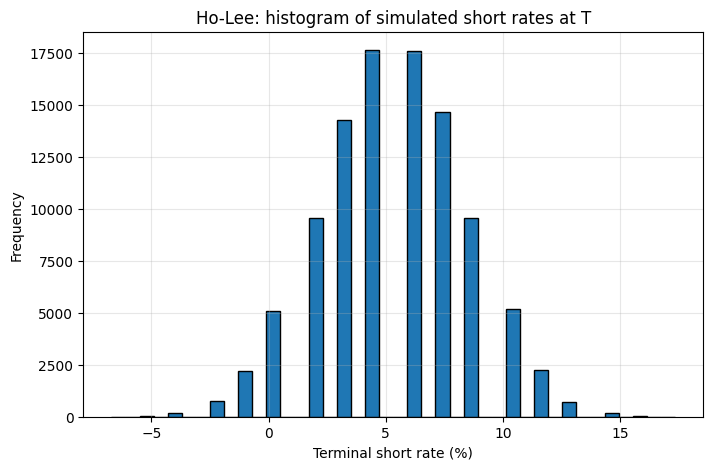

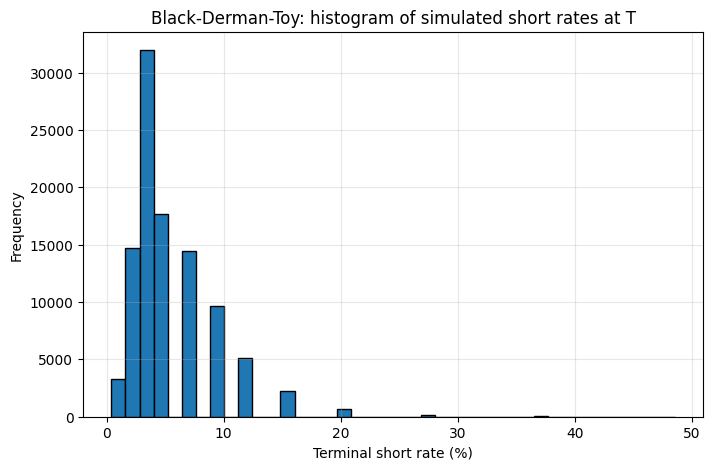

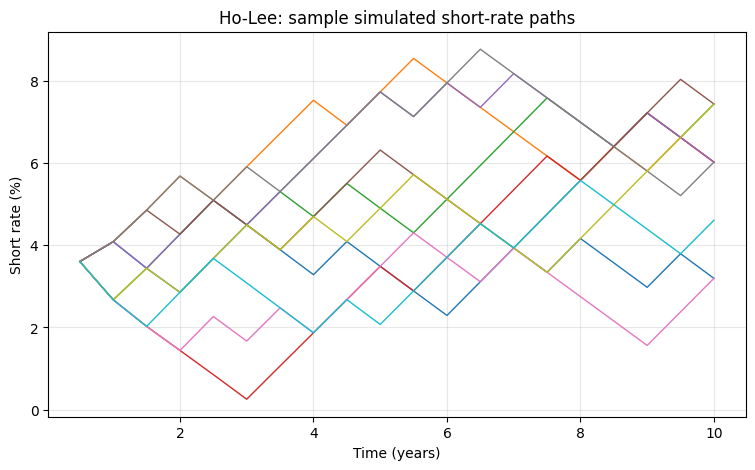

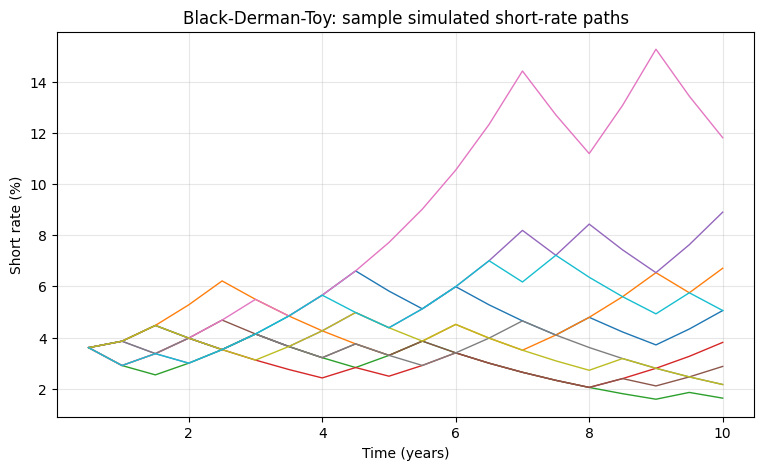

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =============================================================================
# PART (D): MONTE CARLO ON THE CALIBRATED BINOMIAL TREES
# Slides-style implementation:
# - simulate directly on the risk-neutral tree
# - q = 0.5 at every step
# - record short-rate paths and plot histogram of terminal-year rate
# =============================================================================

# Assignment setting for code implementations
N_SIM = 100_000
SEED = 12345

def simulate_paths_from_tree(tree, N=100_000, seed=12345):
    """
    Simulate short-rate paths directly on a calibrated binomial tree.

    Parameters
    ----------
    tree : list of arrays
        tree[i][j] = short rate at step i, node j
        Here step i corresponds to time (i+1)*dt in your stored format.
    N : int
        number of Monte Carlo simulations
    seed : int
        RNG seed

    Returns
    -------
    paths : ndarray, shape (N, M)
        Simulated short-rate paths.
        Column i is the short rate at tree step i.
    terminal_rates : ndarray, shape (N,)
        Final-step short rates.
    terminal_nodes : ndarray, shape (N,)
        Final node indices.
    """
    rng = np.random.default_rng(seed)

    M = len(tree)
    paths = np.zeros((N, M), dtype=float)
    node_idx = np.zeros(N, dtype=int)

    # Root rate
    paths[:, 0] = float(tree[0][0])

    # Move through the tree with RN probability q = 0.5
    for i in range(1, M):
        # In your stored trees, node index increasing means higher-rate branch
        up = rng.random(N) < 0.5
        node_idx = node_idx + up.astype(int)
        paths[:, i] = np.asarray(tree[i], dtype=float)[node_idx]

    terminal_rates = paths[:, -1].copy()
    terminal_nodes = node_idx.copy()

    return paths, terminal_rates, terminal_nodes


def summarize_terminal_rates(rates, model_name):
    """
    Produce summary statistics for terminal rates.
    """
    return {
        "model": model_name,
        "n_sims": len(rates),
        "mean": float(np.mean(rates)),
        "std": float(np.std(rates, ddof=1)),
        "min": float(np.min(rates)),
        "p01": float(np.quantile(rates, 0.01)),
        "p05": float(np.quantile(rates, 0.05)),
        "median": float(np.quantile(rates, 0.50)),
        "p95": float(np.quantile(rates, 0.95)),
        "p99": float(np.quantile(rates, 0.99)),
        "max": float(np.max(rates)),
        "prob_negative": float(np.mean(rates < 0.0)),
    }


def plot_terminal_histogram(rates, model_name, bins=40):
    """
    Histogram of terminal short rates.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(rates * 100.0, bins=bins, edgecolor="black")
    ax.set_xlabel("Terminal short rate (%)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{model_name}: histogram of simulated short rates at T")
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_sample_paths(paths, model_name, dt=0.5, n_show=10):
    """
    Optional: plot a few sample simulated paths, like the slides.
    """
    M = paths.shape[1]
    t_grid = np.arange(dt, (M + 1) * dt, dt)

    fig, ax = plt.subplots(figsize=(9, 5))
    for k in range(min(n_show, paths.shape[0])):
        ax.plot(t_grid, paths[k, :] * 100.0, linewidth=1.0)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Short rate (%)")
    ax.set_title(f"{model_name}: sample simulated short-rate paths")
    ax.grid(True, alpha=0.3)
    plt.show()


# =============================================================================
# RUN PART (D)
# =============================================================================

# Simulate on the calibrated trees from part (a)
hl_paths, hl_terminal_rates, hl_terminal_nodes = simulate_paths_from_tree(
    hl_tree, N=N_SIM, seed=SEED
)

bdt_paths, bdt_terminal_rates, bdt_terminal_nodes = simulate_paths_from_tree(
    bdt_tree, N=N_SIM, seed=SEED + 1
)

# Summary tables
part_d_summary = pd.DataFrame([
    summarize_terminal_rates(hl_terminal_rates, "HL"),
    summarize_terminal_rates(bdt_terminal_rates, "BDT"),
])

print("\nPart (d) summary: simulated short rates at T")
print(part_d_summary.to_string(index=False))

# Histograms required by the assignment
plot_terminal_histogram(hl_terminal_rates, "Ho-Lee", bins=40)
plot_terminal_histogram(bdt_terminal_rates, "Black-Derman-Toy", bins=40)

# Optional: sample paths, closer to the Appendix slides
plot_sample_paths(hl_paths, "Ho-Lee", dt=dt, n_show=10)
plot_sample_paths(bdt_paths, "Black-Derman-Toy", dt=dt, n_show=10)

In [11]:
import numpy as np
import pandas as pd

# =============================================================================
# PART (E): MONTE CARLO REVALUATION OF THE MORTGAGE UNDER BDT
# Slides-consistent implementation
# =============================================================================

N_SIM = 100_000
SEED = 12345

def simulate_node_paths(tree, N=100_000, seed=12345):
    """
    Simulate risk-neutral node paths on the calibrated binomial tree.
    node_paths[s, i] = node index visited by simulation s at step i.
    """
    rng = np.random.default_rng(seed)
    M = len(tree)

    node_paths = np.zeros((N, M), dtype=int)

    for i in range(1, M):
        up = rng.random(N) < 0.5
        node_paths[:, i] = node_paths[:, i - 1] + up.astype(int)

    return node_paths


def build_mortgage_exercise_boundary(tree, K, L0=100.0, T=10.0, dt=0.5, tol=1e-12):
    """
    Rebuild the exact mortgage trees from part (b), then infer the exercise region
    using the slides' rule:
        exercise if C_ex > C_wait
    with no exercise at i = 0.
    """
    M = int(round(T / dt))

    res = price_mortgage_notes_style(tree, K, L0=L0, T=T, dt=dt)
    Vnp_tree = res["Vnp_tree"]
    C_tree = res["C_tree"]
    L = res["balance_schedule"]
    A = res["payment"]

    exercise = [np.zeros(i + 1, dtype=bool) for i in range(M)]

    for i in range(1, M):  # no exercise at origination
        r_i = np.asarray(tree[i], dtype=float)
        Vnp_i = np.asarray(Vnp_tree[i], dtype=float)
        C_next = np.asarray(C_tree[i + 1], dtype=float)

        for j in range(i + 1):
            C_ex = max(Vnp_i[j] - L[i], 0.0)
            C_wait = np.exp(-r_i[j] * dt) * (0.5 * C_next[j] + 0.5 * C_next[j + 1])

            # Slides say: exercise whenever C_ex > C_wait
            exercise[i][j] = (C_ex > C_wait + tol)

    return {
        "exercise": exercise,
        "balance_schedule": L,
        "payment": A,
        "tree_value": float(res["V0_mortgage"]),
    }


def mortgage_mc_bdt_slides(tree, K, L0=100.0, T=10.0, dt=0.5,
                           N=100_000, seed=12345):
    """
    Slides-style MC:
    - simulate many random paths on the BDT tree
    - use the exact mortgage exercise rule from the tree
    - value each simulated path by backward recursion on the realized path
    - report mean, SE, CI = [mean - 2SE, mean + 2SE]
    """
    M = int(round(T / dt))
    if len(tree) != M:
        raise ValueError(f"Tree length {len(tree)} does not match M={M}.")

    info = build_mortgage_exercise_boundary(tree, K, L0=L0, T=T, dt=dt)
    exercise = info["exercise"]
    L = info["balance_schedule"]
    A = info["payment"]
    tree_value = info["tree_value"]

    node_paths = simulate_node_paths(tree, N=N, seed=seed)

    # Backward valuation along each realized path
    v = np.zeros(N, dtype=float)

    for i in range(M - 1, -1, -1):
        j = node_paths[:, i]
        r_i = np.asarray(tree[i], dtype=float)[j]

        cont = np.exp(-r_i * dt) * (A + v)

        if i == 0:
            # no exercise at origination
            v = cont
        else:
            ex = exercise[i][j]
            v = np.where(ex, L[i], cont)

    pv_paths = v

    # First prepayment time, for diagnostics only
    prepay_step = np.full(N, -1, dtype=int)
    alive = np.ones(N, dtype=bool)
    for i in range(1, M):
        ex_i = exercise[i][node_paths[:, i]]
        hit = alive & ex_i
        prepay_step[hit] = i
        alive[hit] = False

    price_hat = float(np.mean(pv_paths))
    sample_std = float(np.std(pv_paths, ddof=1))
    std_err = sample_std / np.sqrt(N)
    ci_low = price_hat - 2.0 * std_err
    ci_high = price_hat + 2.0 * std_err

    prepaid_mask = prepay_step >= 0
    prepay_prob = float(np.mean(prepaid_mask))
    avg_prepay_time = float(dt * np.mean(prepay_step[prepaid_mask])) if prepaid_mask.any() else np.nan

    return {
        "price_hat": price_hat,
        "sample_std": sample_std,
        "std_err": std_err,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "tree_value": tree_value,
        "tree_value_in_CI": bool(ci_low <= tree_value <= ci_high),
        "pv_paths": pv_paths,
        "node_paths": node_paths,
        "prepay_step": prepay_step,
        "prepay_prob": prepay_prob,
        "avg_prepay_time_years": avg_prepay_time,
        "payment": A,
        "balance_schedule": L,
    }


# =============================================================================
# RUN PART (E)
# =============================================================================

res_e = mortgage_mc_bdt_slides(
    tree=bdt_tree,
    K=K_BDT,
    L0=L0,
    T=T,
    dt=dt,
    N=N_SIM,
    seed=SEED
)

part_e_summary = pd.DataFrame([{
    "model": "BDT",
    "mortgage_rate": K_BDT,
    "tree_value_part_b": res_e["tree_value"],
    "mc_price_hat": res_e["price_hat"],
    "std_err": res_e["std_err"],
    "ci_low_95_slides": res_e["ci_low"],
    "ci_high_95_slides": res_e["ci_high"],
    "tree_value_in_CI": res_e["tree_value_in_CI"],
    "prepay_prob_MC": res_e["prepay_prob"],
    "avg_prepay_time_years": res_e["avg_prepay_time_years"],
}])

print("\nPart (e) results")
print(part_e_summary.to_string(index=False))

print("\nFirst 10 path values:")
print(np.round(res_e["pv_paths"][:10], 6))


Part (e) results
model  mortgage_rate  tree_value_part_b  mc_price_hat  std_err  ci_low_95_slides  ci_high_95_slides  tree_value_in_CI  prepay_prob_MC  avg_prepay_time_years
  BDT       0.046885              100.0     99.995143  0.00729         99.980563         100.009722              True         0.89947                1.20317

First 10 path values:
[100.884898  95.358454 100.516551 100.516551 100.884898 101.388961
 100.516551  95.869618 100.516551 100.516551]
